#### Chain Of Thoughts With RAG
What is Chain-of-Thought (CoT) in RAG?

CoT reasoning breaks down a complex question into intermediate steps, and allows retrieval + reflection at each step before answering.

User Query
   ↓
- Step 1: Decompose question → sub-steps (Reason)
- Step 2: Retrieve docs per step (Act)
- Step 3: Combine context (Observe)
- Step 4: Final answer generation (Reflect)

In [1]:
import os
from typing import List
from pydantic import BaseModel
from langchain_core.documents import Document
from langchain_ollama import OllamaEmbeddings
from langchain_community.document_loaders import TextLoader
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import StateGraph, END

C:\Users\harsh\AppData\Local\Temp\ipykernel_27936\3848882679.py:6: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import TextLoader


In [2]:
# -------------------------------
# 1. Prepare Vectorstore
# -------------------------------
docs = TextLoader("research_notes.txt",encoding="utf-8").load()
splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
chunks = splitter.split_documents(docs)
embedding = OllamaEmbeddings(model="nomic-embed-text")
vectorstore = FAISS.from_documents(chunks, embedding)
retriever = vectorstore.as_retriever()

In [18]:
import os
from langchain_groq import ChatGroq
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0
)

In [19]:
# -------------------------------
# 2. LangGraph State Definition
# -------------------------------
class RAGCoTState(BaseModel):
    question: str
    sub_steps: List[str] = []
    retrieved_docs: List[Document] = []
    answer: str = ""

In [20]:
# -------------------------------
# 3. Nodes
# -------------------------------

# a. Plan sub-questions
def plan_steps(state:RAGCoTState)->RAGCoTState:
    prompt=f"Break the question into 2-3 reasoning steps: \n\n {state.question}"
    result=llm.invoke(prompt).content
    subqs=[line.strip("- ") for line in result.split("\n") if line.strip()]

    return state.model_copy(update={"sub_steps":subqs})


In [21]:
# b. Retrieve for each step
def retrieve_per_step(state:RAGCoTState)-> RAGCoTState:
    all_docs=[]
    for sub in state.sub_steps:
        docs = retriever.invoke(sub)
        all_docs.extend(docs)
    return state.model_copy(update={"retrieved_docs": all_docs})

In [22]:
# c. Generate Final Answer
def generate_answer(state: RAGCoTState) -> RAGCoTState:
    
    context = "\n\n".join([doc.page_content for doc in state.retrieved_docs])
    prompt = f"""
    You are answering a complex question using reasoning and retrieved documents.

    Question: {state.question}

    Relevant Information:
    {context}

    Now synthesize a well-reasoned final answer.
    """
    result = llm.invoke(prompt).content.strip()
    return state.model_copy(update={"answer": result})

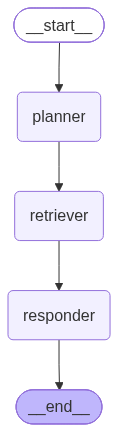

In [23]:
# -------------------------------
# 4. LangGraph Graph
# -------------------------------
builder = StateGraph(RAGCoTState)
builder.add_node("planner", plan_steps)
builder.add_node("retriever", retrieve_per_step)
builder.add_node("responder", generate_answer)

builder.set_entry_point("planner")
builder.add_edge("planner", "retriever")
builder.add_edge("retriever", "responder")
builder.add_edge("responder", END)

graph = builder.compile()
graph

In [24]:
# -------------------------------
# 5. Run CoT RAG Agent
# -------------------------------
if __name__ == "__main__":
    query = "what are the additional eperiments in Transformer eveluation?"
    state = RAGCoTState(question=query)
    final = graph.invoke(state)

    print("\n🪜 Reasoning Steps:", final["sub_steps"])
    print("\n✅ Final Answer:\n", final["answer"])


🪜 Reasoning Steps: ["To address the question of additional experiments in Transformer evaluation, let's break it down into reasoning steps:", '1. **Understanding Transformer Basics**: The first step is to understand what Transformers are and their primary function. Transformers are a type of neural network architecture introduced in the paper "Attention Is All You Need" by Vaswani et al. in 2017. They are primarily used for sequence-to-sequence tasks and have shown state-of-the-art results in many natural language processing (NLP) tasks. Understanding the basic architecture, including self-attention mechanisms, encoder-decoder structure, and the role of positional encoding, is crucial.', '2. **Identifying Evaluation Metrics and Tasks**: The next step involves identifying the common evaluation metrics and tasks used to assess the performance of Transformers. These typically include metrics such as BLEU (Bilingual Evaluation Understudy) score for translation tasks, ROUGE score for summa

In [25]:
# -------------------------------
# 5. Run CoT RAG Agent
# -------------------------------
if __name__ == "__main__":
    query = "what are the different levels of memory systems required in Agentic AI Systems"
    state = RAGCoTState(question=query)
    final = graph.invoke(state)

    print("\n🪜 Reasoning Steps:", final["sub_steps"])
    print("\n✅ Final Answer:\n", final["answer"])


🪜 Reasoning Steps: ['To address the question of the different levels of memory systems required in Agentic AI Systems, we can break it down into the following reasoning steps:', '1. **Understanding Agentic AI Systems**: First, we need to understand what Agentic AI Systems are. Agentic AI refers to artificial intelligence systems that are designed to act autonomously, making decisions and taking actions based on their environment, goals, and internal state. These systems are typically characterized by their ability to perceive their environment, reason about it, and act upon it to achieve specific objectives.', '2. **Identifying Memory Requirements**: Next, we consider the role of memory in Agentic AI Systems. Memory is crucial for these systems as it enables them to learn from their experiences, recall past events, and make informed decisions based on historical data. The memory requirements can be categorized based on the type of information that needs to be stored and the duration f